In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
import numpy as np
import tensorflow as tf
from tensorflow import keras
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.model_selection import KFold

c:\Users\Samuel\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# 1. Definir las rutas de los archivos CSV preprocesados
path_train = "dfFinalMA_Train/MA_TRAIN.csv"
path_test  = "dfFinalMA_Test/MA_Test.csv"

# 2. Cargar los datasets
df_train = pd.read_csv(path_train)
df_test  = pd.read_csv(path_test)

# 3. Verificación de carga
print("==============================================")
print("        DATASETS CARGADOS CON ÉXITO           ")
print("==============================================")
print(f"Dimensiones de Train: {df_train.shape[0]} filas, {df_train.shape[1]} columnas")
print(f"Dimensiones de Test:  {df_test.shape[0]} filas, {df_test.shape[1]} columnas")

print("\n--- Tipos de datos en Train ---")
print(df_train.dtypes)

print("\n--- Primeras 5 filas de Train ---")
display(df_train.head())

        DATASETS CARGADOS CON ÉXITO           
Dimensiones de Train: 6375 filas, 15 columnas
Dimensiones de Test:  1608 filas, 15 columnas

--- Tipos de datos en Train ---
User_ID                       object
Age                            int64
Gender                        object
User_Archetype                object
Primary_Platform              object
Daily_Screen_Time_Hours      float64
Dominant_Content_Type         object
Activity_Type                 object
Late_Night_Usage                bool
Social_Comparison_Trigger       bool
Sleep_Duration_Hours         float64
GAD_7_Score                    int64
GAD_7_Severity                object
PHQ_9_Score                    int64
PHQ_9_Severity                object
dtype: object

--- Primeras 5 filas de Train ---


,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
0,U-00061085,19,MALE,PASSIVE SCROLLER,FACEBOOK,4.0,NEWS/POLITICS,PASSIVE,True,False,5.8,8,MILD,8,MILD
1,U-00088ACC,20,MALE,PASSIVE SCROLLER,TIKTOK,4.0,NEWS/POLITICS,PASSIVE,True,False,4.2,10,MODERATE,7,MILD
2,U-000A7FEC,20,MALE,AVERAGE USER,INSTAGRAM,3.6,LIFESTYLE/FASHION,ACTIVE,False,True,6.9,10,MODERATE,0,NONE-MINIMAL
3,U-00228E6E,19,MALE,PASSIVE SCROLLER,YOUTUBE,3.1,LIFESTYLE/FASHION,PASSIVE,False,False,6.2,7,MILD,9,MILD
4,U-00262C0F,18,FEMALE,AVERAGE USER,LINKEDIN,2.4,EDUCATIONAL/TECH,ACTIVE,False,False,6.4,9,MILD,1,NONE-MINIMAL


In [4]:
# 1. Definir la variable objetivo
target_col = "GAD_7_Score"

columnas_a_dropear = [
    "User_ID",                 
    "GAD_7_Severity",
    "PHQ_9_Score",
    "PHQ_9_Severity"
]

# 3. Separar X (Características) e y (Variable Objetivo) para TRAIN
X_train = df_train.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_train = df_train[target_col]

# 4. Separar X e y para TEST
X_test = df_test.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_test = df_test[target_col]

# 5. Comprobación
print("==============================================")
print("        SEPARACIÓN Y LIMPIEZA COMPLETADA      ")
print("==============================================")
print(f"Dimensiones de X_train (Predictoras): {X_train.shape}")
print(f"Dimensiones de y_train (Objetivo):    {y_train.shape}")
print(f"Dimensiones de X_test (Predictoras):  {X_test.shape}")
print(f"Dimensiones de y_test (Objetivo):     {y_test.shape}")

print("\nColumnas que usará el modelo para aprender:")
print(list(X_train.columns))

        SEPARACIÓN Y LIMPIEZA COMPLETADA      
Dimensiones de X_train (Predictoras): (6375, 10)
Dimensiones de y_train (Objetivo):    (6375,)
Dimensiones de X_test (Predictoras):  (1608, 10)
Dimensiones de y_test (Objetivo):     (1608,)

Columnas que usará el modelo para aprender:
['Age', 'Gender', 'User_Archetype', 'Primary_Platform', 'Daily_Screen_Time_Hours', 'Dominant_Content_Type', 'Activity_Type', 'Late_Night_Usage', 'Social_Comparison_Trigger', 'Sleep_Duration_Hours']


In [5]:
# 1. Identificar cuáles son las columnas numéricas
# Seleccionamos solo las columnas de tipo entero y decimal
columnas_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns

print(f"Se van a escalar las siguientes columnas numéricas:\n{list(columnas_numericas)}\n")

# 2. Inicializar el StandardScaler
scaler = StandardScaler()

# 3. AjustaR  y transformar 
X_train[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

# ==========================================
# 5. Comprobación de que se hizo correctamente
# ==========================================
print("--- Comprobación en TRAIN ---")
print("La media de Train debería ser muy cercana a 0:")
print(X_train[columnas_numericas].mean().round(2))
print("\nLa desviación estándar de Train debería ser 1:")
print(X_train[columnas_numericas].std().round(2))

print("\n--- Primeras filas de X_train escalado ---")
display(X_train.head()) 

Se van a escalar las siguientes columnas numéricas:
['Age', 'Daily_Screen_Time_Hours', 'Sleep_Duration_Hours']

--- Comprobación en TRAIN ---
La media de Train debería ser muy cercana a 0:
Age                       -0.0
Daily_Screen_Time_Hours    0.0
Sleep_Duration_Hours       0.0
dtype: float64

La desviación estándar de Train debería ser 1:
Age                        1.0
Daily_Screen_Time_Hours    1.0
Sleep_Duration_Hours       1.0
dtype: float64

--- Primeras filas de X_train escalado ---


,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours
0,-0.050239,MALE,PASSIVE SCROLLER,FACEBOOK,-0.107376,NEWS/POLITICS,PASSIVE,True,False,-0.015770
1,0.846880,MALE,PASSIVE SCROLLER,TIKTOK,-0.107376,NEWS/POLITICS,PASSIVE,True,False,-1.215309
2,0.846880,MALE,AVERAGE USER,INSTAGRAM,-0.281100,LIFESTYLE/FASHION,ACTIVE,False,True,0.808913
3,-0.050239,MALE,PASSIVE SCROLLER,YOUTUBE,-0.498256,LIFESTYLE/FASHION,PASSIVE,False,False,0.284114
4,-0.947357,FEMALE,AVERAGE USER,LINKEDIN,-0.802275,EDUCATIONAL/TECH,ACTIVE,False,False,0.434057


In [6]:
# 1. Definir qué columnas son categóricas
columnas_categoricas = ['Gender', 'User_Archetype', 'Primary_Platform', 'Dominant_Content_Type','Activity_Type']

# 2. Aplicar One-Hot Encoding a Train y Test
X_train_codificado = pd.get_dummies(X_train, columns=columnas_categoricas, drop_first=True)
X_test_codificado = pd.get_dummies(X_test, columns=columnas_categoricas, drop_first=True)

# 3. ALINEAR Train y Test
X_train_codificado, X_test_codificado = X_train_codificado.align(X_test_codificado, join='left', axis=1, fill_value=0)

print(f"Columnas finales para entrenar: {X_train_codificado.shape[1]}")

Columnas finales para entrenar: 21


In [8]:
# 1. PREPARACIÓN DE DATOS RÁPIDA PARA OPTUNA
# Dividimos tu X_train_codificado en Train y Validación interna
X_tr, X_val, y_tr, y_val = train_test_split(X_train_codificado, y_train, test_size=0.2, random_state=42)

# Convertimos a Tensores (usando tus variables reales)
X_tr_tensor = torch.tensor(X_tr.astype(np.float32).values, dtype=torch.float32)
y_tr_tensor = torch.tensor(y_tr.astype(np.float32).values, dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val.astype(np.float32).values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.astype(np.float32).values, dtype=torch.float32).unsqueeze(1)

# DataLoader
train_loader = DataLoader(TensorDataset(X_tr_tensor, y_tr_tensor), batch_size=64, shuffle=True)

# 2. DEFINIMOS LA FUNCIÓN DE BÚSQUEDA
def objective(trial):
    # --- A. Optuna "adivina" los hiperparámetros ---
    # Le decimos que pruebe entre 1 y 4 capas ocultas
    n_layers = trial.suggest_int('n_layers', 1, 4) 
    # Que pruebe un dropout entre 10% y 50%
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5) 
    # Que pruebe diferentes tasas de aprendizaje (learning rate)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True) 
    
    # --- B. Construimos la red neuronal dinámicamente ---
    layers = []
    in_features = X_train_codificado.shape[1] # Tus 31 columnas de entrada
    
    for i in range(n_layers):
        # Para cada capa, Optuna decide si pone entre 16 y 128 neuronas
        out_features = trial.suggest_int(f'n_units_l{i}', 16, 128) 
        
        layers.append(nn.Linear(in_features, out_features))
        layers.append(nn.BatchNorm1d(out_features))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout_rate))
        
        in_features = out_features # La salida de esta capa es la entrada de la siguiente
        
    # Capa final de salida (1 neurona para predecir el Mental Wellbeing Score)
    layers.append(nn.Linear(in_features, 1))
    
    # Empaquetamos la red
    model = nn.Sequential(*layers)
    
    # --- C. Entrenamos el modelo ---
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    model.train()
    # Entrenamos solo por 50 épocas para que la búsqueda sea rápida
    for epoch in range(50): 
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            pred = model(batch_X)
            loss = criterion(pred, batch_y)
            loss.backward()
            optimizer.step()
            
    # --- D. Evaluamos qué tan buena fue esta arquitectura ---
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_tensor)
        val_loss = criterion(val_preds, y_val_tensor).item() # Calculamos el error
        
    return val_loss # Le decimos a Optuna que su objetivo es minimizar este error

# 3. EJECUTAMOS LA BÚSQUEDA MÁGICA
print("Iniciando búsqueda de la mejor Red Neuronal...")
study = optuna.create_study(direction='minimize')
# Le pedimos que construya y pruebe 20 redes neuronales distintas
study.optimize(objective, n_trials=50) 

print("\n==============================================")
print("¡BÚSQUEDA TERMINADA! LA MEJOR RED NEURONAL ES:")
print("==============================================")
print(study.best_params)

[I 2026-08-28 06:34:55,615] A new study created in memory with name: no-name-616e31b3-faac-4102-bd1d-6feccd7a79fe


Iniciando búsqueda de la mejor Red Neuronal...


[I 2026-08-28 06:35:02,709] Trial 0 finished with value: 8.864355087280273 and parameters: {'n_layers': 2, 'dropout_rate': 0.18769253524810445, 'lr': 0.008777749659635733, 'n_units_l0': 80, 'n_units_l1': 119}. Best is trial 0 with value: 8.864355087280273.
[I 2026-08-28 06:35:11,765] Trial 1 finished with value: 7.843925476074219 and parameters: {'n_layers': 2, 'dropout_rate': 0.39044954680539024, 'lr': 0.007339743009551395, 'n_units_l0': 87, 'n_units_l1': 126}. Best is trial 1 with value: 7.843925476074219.
[I 2026-08-28 06:35:18,931] Trial 2 finished with value: 8.102025032043457 and parameters: {'n_layers': 1, 'dropout_rate': 0.4767706832212625, 'lr': 0.006563943747786544, 'n_units_l0': 17}. Best is trial 1 with value: 7.843925476074219.
[I 2026-08-28 06:35:32,586] Trial 3 finished with value: 8.083894729614258 and parameters: {'n_layers': 3, 'dropout_rate': 0.2556084300625331, 'lr': 0.0010641129379722028, 'n_units_l0': 127, 'n_units_l1': 89, 'n_units_l2': 119}. Best is trial 1 with


¡BÚSQUEDA TERMINADA! LA MEJOR RED NEURONAL ES:
{'n_layers': 1, 'dropout_rate': 0.19831283149799533, 'lr': 0.000622662870516253, 'n_units_l0': 104}


In [11]:
# ==========================================
# 1. DEFINICIÓN DEL MODELO (1 Capa - 104 Neuronas)
# ==========================================
class TabularRegressionModel(nn.Module):
    def __init__(self, num_features, dropout_rate=0.1983):
        super(TabularRegressionModel, self).__init__()

        self.tabular_model = nn.Sequential(
            # Única capa oculta optimizada
            nn.Linear(num_features, 104),
            nn.BatchNorm1d(104),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate)
        )

        # Capa de salida directa
        self.regression = nn.Sequential(
            nn.Linear(104, 1)
        )

    def forward(self, x):
        features = self.tabular_model(x)
        return self.regression(features)

# ==========================================
# 2. CONFIGURACIÓN DE K-FOLD Y DATOS
# ==========================================
X_tensor = torch.tensor(X_train_codificado.astype(np.float32).values, dtype=torch.float32)
y_tensor = torch.tensor(y_train.astype(np.float32).values, dtype=torch.float32).unsqueeze(1)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_r2_scores = []

batch_size = 64
max_epochs = 300
patience = 25  

# ==========================================
# 3. ENTRENAMIENTO CON VALIDACIÓN CRUZADA
# ==========================================
for fold, (train_idx, val_idx) in enumerate(kf.split(X_tensor)):
    print(f"\n--- FOLD {fold + 1} ---")
    
    X_tr, y_tr = X_tensor[train_idx], y_tensor[train_idx]
    X_va, y_va = X_tensor[val_idx], y_tensor[val_idx]

    train_dataset = TensorDataset(X_tr, y_tr)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model = TabularRegressionModel(num_features=X_tensor.shape[1])
    criterion = nn.MSELoss()
    
    # Optimizador con el Learning Rate exacto (0.00062266...)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.00062266, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=25
    )

    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_r2 = 0

    for epoch in range(max_epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(X_va)
            val_loss = criterion(val_preds, y_va).item()
            r2 = r2_score(y_va.numpy(), val_preds.numpy())
            
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_r2 = r2
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early Stopping en la época {epoch + 1}. Mejor R2 del Fold: {best_r2:.4f}")
            break

    fold_r2_scores.append(best_r2)

print("\n==============================================")
print(f"R² Promedio Final (19 Neuronas): {np.mean(fold_r2_scores):.4f} (+/- {np.std(fold_r2_scores):.4f})")
print("==============================================")


--- FOLD 1 ---
Early Stopping en la época 69. Mejor R2 del Fold: 0.6383

--- FOLD 2 ---
Early Stopping en la época 111. Mejor R2 del Fold: 0.5851

--- FOLD 3 ---
Early Stopping en la época 80. Mejor R2 del Fold: 0.6091

--- FOLD 4 ---
Early Stopping en la época 118. Mejor R2 del Fold: 0.6078

--- FOLD 5 ---
Early Stopping en la época 75. Mejor R2 del Fold: 0.5916

R² Promedio Final (19 Neuronas): 0.6064 (+/- 0.0184)


--- Resultados en Test ---
RMSE: 2.9626
MAE:  2.4072
R2:   0.6069


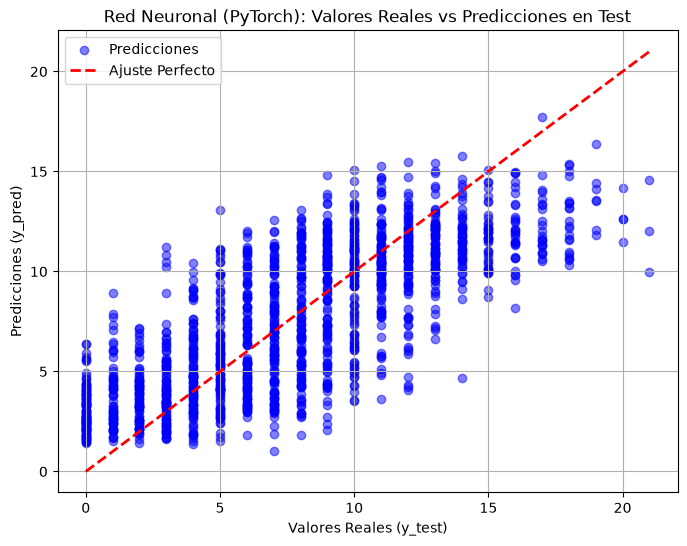

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Preparar los datos de prueba y predecir con el modelo PyTorch
# Convertimos el DataFrame de test a Tensor
X_test_tensor = torch.tensor(X_test_codificado.astype(np.float32).values, dtype=torch.float32)

# Modo evaluación para desactivar el Dropout
model.eval()
with torch.no_grad():
    # Hacemos la predicción y convertimos a un array unidimensional de NumPy
    y_pred = model(X_test_tensor).numpy().flatten()

y_test_original = y_test.values if isinstance(y_test, pd.Series) else y_test

# 2. Métricas en escala real
rmse_test = np.sqrt(mean_squared_error(y_test_original, y_pred))
mae_test = mean_absolute_error(y_test_original, y_pred)
r2_test = r2_score(y_test_original, y_pred)

print("--- Resultados en Test ---")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE:  {mae_test:.4f}")
print(f"R2:   {r2_test:.4f}")

# 3. Visualización
plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5, color='b', label='Predicciones')

min_val = min(np.min(y_test_original), np.min(y_pred))
max_val = max(np.max(y_test_original), np.max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ajuste Perfecto')

plt.xlabel('Valores Reales (y_test)')
plt.ylabel('Predicciones (y_pred)')
plt.title('Red Neuronal (PyTorch): Valores Reales vs Predicciones en Test')
plt.legend()
plt.grid(True)
plt.show()